#Домашнє завдання

Налаштувалися на виконання нового завдання? Тодi полетiли!

Сьогодні ви використаєте розклад SVD для стиснення зображень. Цей підхід може знадобитись при обробці цифрових сигналів при підготовці даних для моделі машинного навчання.

Це допоможе закрiпити такі навички:  

- Робота з матричним поданням зображень.
- Застосування матричних докомпозицій.

##Завдання (крок за кроком)

Для цієї задачі використайте файл, котрий ви отримали у результаті виконання першого ДЗ.

1. Підготуйте декілька зображень. Це можуть бути RGB або зображення у градації сірого, наприклад, у jpg форматі.

2. Виведіть зображення в Colab за допомогою функції imread з бібліотеки matplotlib.
3. Визначить розмір зображення за допомогою функції shape.
4. Оскільки SVD можна застосувати лише до 2D-даних, ми можемо або виконати його для кожного каналу кольору окремо, або ми можемо змінити форму зображення з 3D-матриці на 2D-матрицю, згладивши кожен колірний канал і склавши їх горизонтально (або вертикально).

Наприклад, можна застосувати функцію reshape, що змінює форму зображення у 2D-матрицю шляхом укладання кольорових каналів горизонтально:

```
height, width, channels = image.shape
flat_image = image.reshape(-1, width * channels)

```
5. Застосуйте SVD декомпозицію за допомогою функції svd з бібліотеки numpy.

6. Візуалізуйте перші $k$ значень матриці Σ. Для цього можна використати matplotlib:
```
plt.plot(np.arange(k), S[:k])
```
7. Якщо на діаграмі ми побачимо суттєве зниження значень власних чисел з матриці Σ, це буде означати, що ми можемо ефективно стиснути зображення без значної втрати точності. Наприклад, щоб скоротити зображення, яке буде відповідати першим 100 значенням можна використовувати алгоритм усіченого SVD (функція TruncatedSVD):

```
svd = TruncatedSVD(n_components= 100 )
truncated_image = svd.fit_transform(flat_image)

```

8. Щоб побачити, скільки інформації було втрачено під час стиснення, ми можемо виміряти помилку реконструкції зображення. Ми вимірюватимемо похибку реконструкції як середнє квадратичних похибок (MSE) між значеннями пікселів оригінального зображення та реконструйованого зображення.

У Scikit-Learn реконструйоване зображення можна отримати викликом методу inverse_transform трансформатора TruncatedSVD:

```
reconstructed_image = svd.inverse_transform(truncated_image)

```
А помилку реконструкції можна розрахувати:
```
reconstruction_error = np.mean(np.square(reconstructed_image - flat_image))
reconstruction_error
```

9. Щоб візуалізувати реконстуйоване зображення, нам спочатку потрібно змінити його форму в оригінальну 3D-форму, а потім обрізати значення пікселів до цілих чисел у діапазоні [0, 255]:
```
reconstructed_image = reconstructed_image.reshape(height, width, channels)
reconstructed_image = np.clip(reconstructed_image, 0 , 255 ).astype( 'uint8' )

plt.imshow(reconstructed_image)
plt.axis( 'off' )

```

10. Виконайте експерименти із використання різних значень $k$ - власних чисел з матриці Σ та візуалізуйте результати. При яких значеннях помітна втрата якості зображення?


### **Підказки**

Для виконання завдання використовуйте функції numpy, sklearn та алгоритми з конспекту до цієї теми.

### **Формат здачі**

Посилання на Google Colab, прикріплений файл ipynb

### **Критерії прийому завдання**

- Усі вказані етапи виконані та проведені обчислювальні експерименти з різними ступенями стискання.
- До Colab додані висновки.

### **Формат оцінювання**

- Залiк / Незалiк

Приклад

Генерація температурної матриці (імітація сенсорних даних)

In [ ]:
import numpy as np
from sklearn.decomposition import TruncatedSVD
import plotly.graph_objs as go
from plotly.subplots import make_subplots
import matplotlib.pyplot as plt

from matplotlib.image import imread
import urllib.request
from PIL import Image
import io



def generate_temperature_matrix(n=100):
    x = np.linspace(0, 10, n)
    y = np.linspace(0, 10, n)
    X, Y = np.meshgrid(x, y)

    Z = (np.sin(X) + np.cos(Y)) * np.exp(-((X - 5)**2 + (Y - 5)**2) / 10)
    Z += 0.2 * np.random.randn(n, n)
    return x, y, Z


Стиснення температурної матриці через TruncatedSVD

In [ ]:
def compress_temperature_matrix(Z, n_components):
    """
    Приводить 2D теплову матрицю до стислого вигляду за допомогою TruncatedSVD і реконструює її.
    """
    height, width = Z.shape
    flat_Z = Z.reshape(height, width)  # Просто переконаємось, що 2D

    svd = TruncatedSVD(n_components=n_components)
    Z_trunc = svd.fit_transform(flat_Z)
    Z_recon = svd.inverse_transform(Z_trunc)

    return np.clip(Z_recon, Z.min(), Z.max())


Оцінка результату стискання

In [ ]:
x, y, Z = generate_temperature_matrix()
k_values = [5, 15, 30, 60]


Text(0, 0.5, 'Magnitude of singular value')

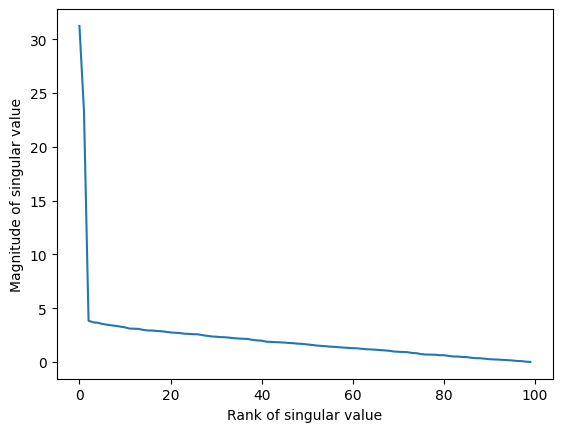

In [ ]:
U, S, Vt = np.linalg.svd(Z)

k = 100
plt.plot(np.arange(k), S[:k])
plt.xlabel('Rank of singular value')
plt.ylabel('Magnitude of singular value')

In [ ]:
fig = make_subplots(
    rows=2, cols=3,
    specs=[[{'type': 'surface'}]*3, [{'type': 'surface'}]*3],
    subplot_titles=["Оригінал", "k=5", "k=15", "k=30", "k=60", ""]
)

fig.add_trace(
    go.Surface(z=Z, x=x, y=y, colorscale='Hot', showscale=False),
    row=1, col=1
)

for idx, k in enumerate(k_values):
    Z_k = compress_temperature_matrix(Z, k)
    fig.add_trace(
        go.Surface(z=Z_k, x=x, y=y, colorscale='Hot', showscale=False),
        row=(idx + 1) // 3 + 1,
        col=(idx + 1) % 3 + 1
    )

fig.update_layout(
    title="TruncatedSVD стискання температурної матриці (3D Plotly)",
    height=800,
    width=1200,
    margin=dict(l=10, r=10, b=10, t=50)
)

fig.show()






Робота із зображеннями

https://medium.com/@fasateaniket5/unlocking-color-codes-a-beginners-guide-to-extracting-rgb-values-from-images-with-python-dd6f8010dba2

Форма зображення (H x W x C): (662, 640, 3)


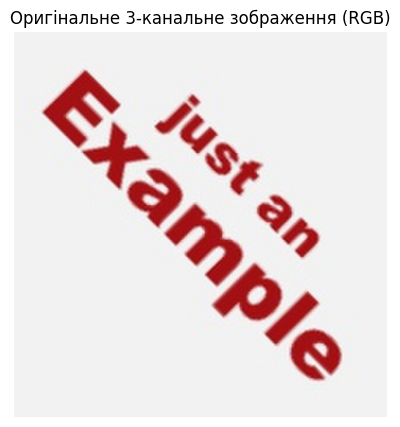

In [ ]:

# 1. Завантаження зображення з інтернету
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/a/a9/Example.jpg/640px-Example.jpg"
with urllib.request.urlopen(url) as response:
    image = Image.open(io.BytesIO(response.read()))
    image = image.convert("RGB")
    image_np = np.array(image)

print("Форма зображення (H x W x C):", image_np.shape)


plt.figure(figsize=(5, 5))
plt.imshow(image_np)
plt.title("Оригінальне 3-канальне зображення (RGB)")
plt.axis("off")
plt.show()


Форма 2-канального зображення: (662, 640, 2)


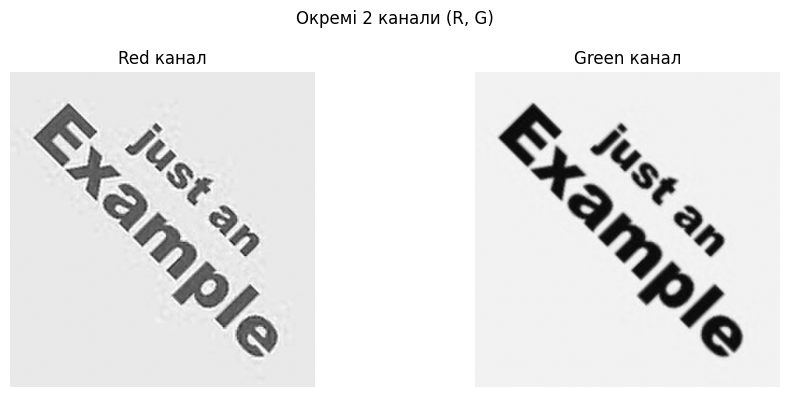

In [ ]:
image_2ch = image_np[:, :, :2]
print("Форма 2-канального зображення:", image_2ch.shape)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
channels = ['Red', 'Green']

for i in range(2):
    axes[i].imshow(image_2ch[:, :, i], cmap='gray')
    axes[i].set_title(f"{channels[i]} канал")
    axes[i].axis("off")

plt.suptitle("Окремі 2 канали (R, G)")
plt.tight_layout()
plt.show()


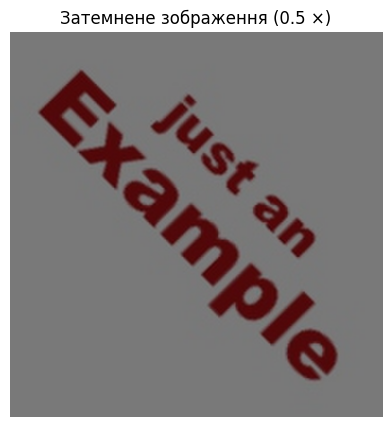

In [ ]:
darkened = (image_np * 0.5).clip(0, 255).astype(np.uint8)

plt.figure(figsize=(5, 5))
plt.imshow(darkened)
plt.title("Затемнене зображення (0.5 ×)")
plt.axis("off")
plt.show()


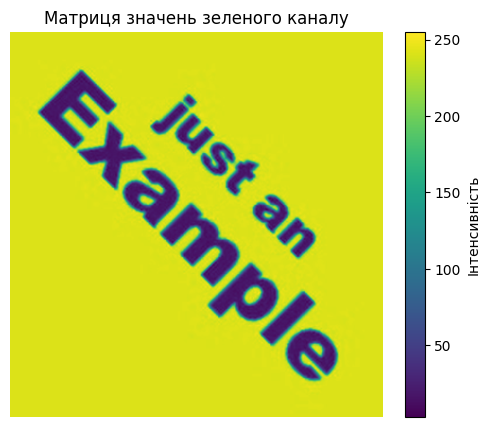

In [ ]:
green_channel = image_np[:, :, 1]
plt.figure(figsize=(6, 5))
plt.imshow(green_channel, cmap='viridis')
plt.title("Матриця значень зеленого каналу")
plt.colorbar(label="Інтенсивність")
plt.axis("off")
plt.show()


## Домашнє завдання: стиснення зображень за допомогою SVD

### 1-2. Підготовка та завантаження зображень

Замість завантаження з інтернету (що потребує доступу з Colab до зовнішніх URL і не завжди стабільно) використаємо кілька еталонних зображень з бібліотеки `scikit-image` — одне у градаціях сірого (`camera`) та два кольорових RGB (`astronaut`, `coffee`). Збережемо їх як `.jpg`-файли на диск і завантажимо назад функцією `imread` з `matplotlib`, як і вимагає завдання.

In [1]:
from skimage import data as skdata
from sklearn.decomposition import TruncatedSVD
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread
from PIL import Image
import os

IMAGE_DIR = "hw2_images"
os.makedirs(IMAGE_DIR, exist_ok=True)

source_images = {
    "astronaut (RGB)": skdata.astronaut(),
    "camera (grayscale)": skdata.camera(),
    "coffee (RGB)": skdata.coffee(),
}

image_paths = {}
for name, arr in source_images.items():
    fname = name.split()[0] + ".jpg"
    path = os.path.join(IMAGE_DIR, fname)
    Image.fromarray(arr).save(path, quality=95)
    image_paths[name] = path

print("Збережені файли:")
for name, path in image_paths.items():
    print(f"  {name}: {path}")

Збережені файли:
  astronaut (RGB): hw2_images\astronaut.jpg
  camera (grayscale): hw2_images\camera.jpg
  coffee (RGB): hw2_images\coffee.jpg


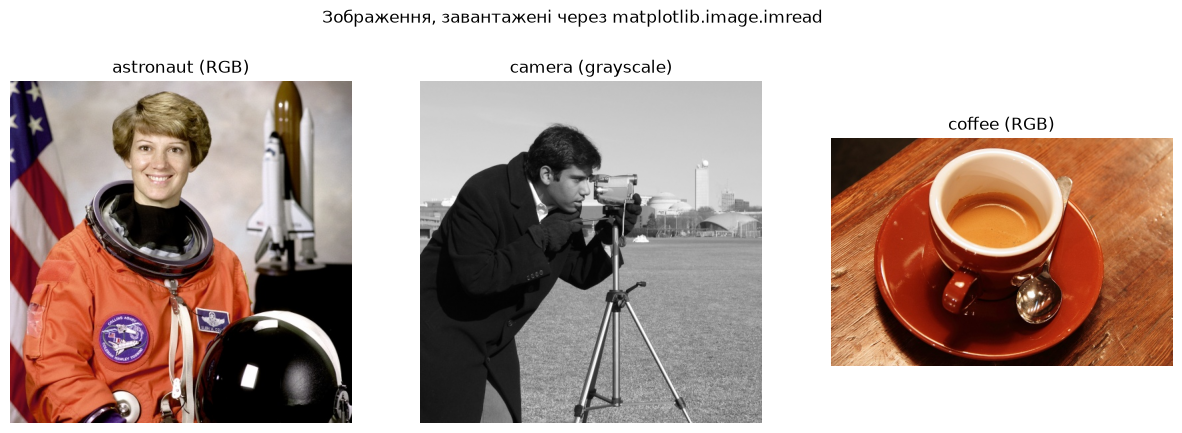

In [2]:
images = {name: imread(path) for name, path in image_paths.items()}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, img) in zip(axes, images.items()):
    cmap = "gray" if img.ndim == 2 else None
    ax.imshow(img, cmap=cmap)
    ax.set_title(name)
    ax.axis("off")
plt.suptitle("Зображення, завантажені через matplotlib.image.imread")
plt.show()

### 3. Розмір зображень (`shape`)

In [3]:
for name, img in images.items():
    print(f"{name}: shape = {img.shape}, dtype = {img.dtype}")

astronaut (RGB): shape = (512, 512, 3), dtype = uint8
camera (grayscale): shape = (512, 512), dtype = uint8
coffee (RGB): shape = (400, 600, 3), dtype = uint8


### 4. Перетворення 3D-зображення у 2D-матрицю

SVD застосовується лише до 2D-даних. Для кольорових зображень "розгортаємо" кольорові канали горизонтально: `(height, width, channels) -> (height, width * channels)`. Зображення у градаціях сірого вже є 2D-матрицею.

In [4]:
def flatten_image(image):
    """Перетворює зображення у 2D-матрицю, придатну для SVD, і повертає її разом з оригінальною формою."""
    if image.ndim == 3:
        height, width, channels = image.shape
        flat = image.reshape(height, width * channels).astype(float)
    else:
        height, width = image.shape
        channels = None
        flat = image.astype(float)
    return flat, (height, width, channels)


flat_images = {}
shapes = {}
for name, img in images.items():
    flat, shape_info = flatten_image(img)
    flat_images[name] = flat
    shapes[name] = shape_info
    print(f"{name}: {img.shape} -> {flat.shape}")

astronaut (RGB): (512, 512, 3) -> (512, 1536)
camera (grayscale): (512, 512) -> (512, 512)
coffee (RGB): (400, 600, 3) -> (400, 1800)


### 5. SVD-декомпозиція (`numpy.linalg.svd`)

In [5]:
svd_results = {}
for name, flat in flat_images.items():
    U, S, Vt = np.linalg.svd(flat, full_matrices=False)
    svd_results[name] = (U, S, Vt)
    print(f"{name}: U {U.shape}, S {S.shape}, Vt {Vt.shape}")

astronaut (RGB): U (512, 512), S (512,), Vt (512, 1536)
camera (grayscale): U (512, 512), S (512,), Vt (512, 512)


coffee (RGB): U (400, 400), S (400,), Vt (400, 1800)


### 6. Візуалізація перших k сингулярних чисел матриці Σ

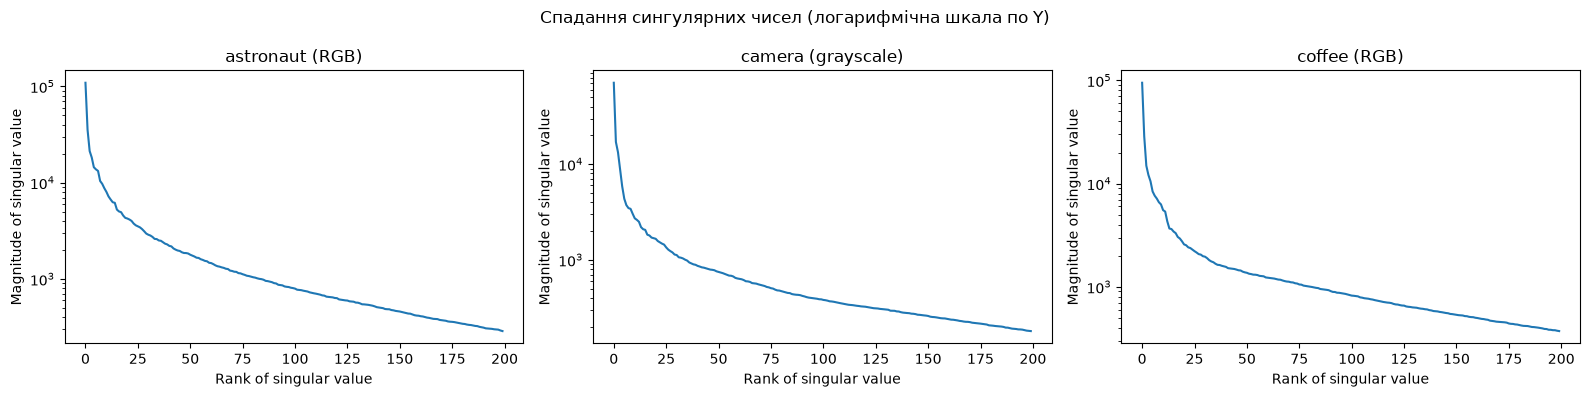

In [6]:
k_plot = 200
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name, (U, S, Vt)) in zip(axes, svd_results.items()):
    ax.plot(np.arange(min(k_plot, len(S))), S[:k_plot])
    ax.set_title(name)
    ax.set_xlabel("Rank of singular value")
    ax.set_ylabel("Magnitude of singular value")
    ax.set_yscale("log")
plt.suptitle("Спадання сингулярних чисел (логарифмічна шкала по Y)")
plt.tight_layout()
plt.show()

Для всіх трьох зображень перші кілька десятків сингулярних чисел значно більші за решту, а далі значення спадають повільно й довгим "хвостом". Це означає, що більшу частину інформації про зображення несуть саме перші компоненти, і зображення можна ефективно стиснути, відкинувши компоненти з малими сингулярними числами.

### 7-9. Стиснення за допомогою TruncatedSVD, похибка реконструкції (MSE) та візуалізація

Демонстрація на прикладі одного значення `k = 50` для зображення `astronaut`.

k = 50, MSE реконструкції = 133.0708


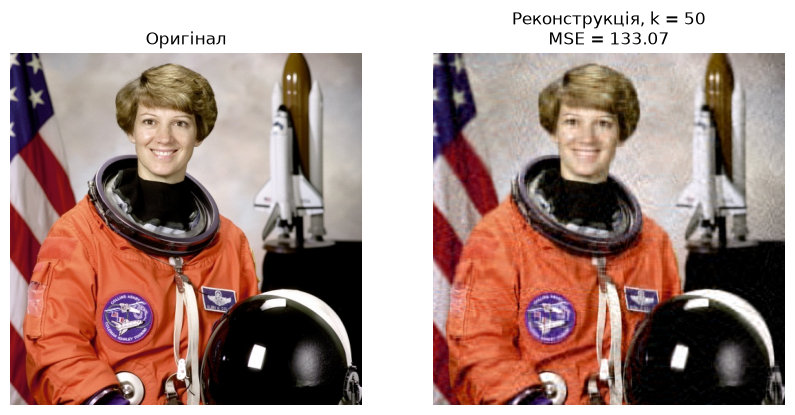

In [7]:
demo_name = "astronaut (RGB)"
flat_image = flat_images[demo_name]
height, width, channels = shapes[demo_name]

k_demo = 50
svd = TruncatedSVD(n_components=k_demo, random_state=42)
truncated_image = svd.fit_transform(flat_image)
reconstructed_image = svd.inverse_transform(truncated_image)

reconstruction_error = np.mean(np.square(reconstructed_image - flat_image))
print(f"k = {k_demo}, MSE реконструкції = {reconstruction_error:.4f}")

reconstructed_image = reconstructed_image.reshape(height, width, channels)
reconstructed_image = np.clip(reconstructed_image, 0, 255).astype("uint8")

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(images[demo_name])
axes[0].set_title("Оригінал")
axes[0].axis("off")
axes[1].imshow(reconstructed_image)
axes[1].set_title(f"Реконструкція, k = {k_demo}\nMSE = {reconstruction_error:.2f}")
axes[1].axis("off")
plt.show()

### 10. Експерименти з різними значеннями k

Для кожного зображення застосуємо стиснення з набором значень `k`, порахуємо похибку реконструкції (MSE) та коефіцієнт стиснення (відношення обсягу стисненого подання `k*(h + w) + k` до обсягу оригінальної матриці `h*w`), і візуалізуємо результати.

In [8]:
def run_svd_experiment(name, k_values):
    flat_image = flat_images[name]
    height, width, channels = shapes[name]
    original_image = images[name]
    h, w = flat_image.shape

    results = []
    reconstructed_by_k = {}
    for k in k_values:
        svd = TruncatedSVD(n_components=k, random_state=42)
        truncated = svd.fit_transform(flat_image)
        reconstructed = svd.inverse_transform(truncated)

        mse = np.mean(np.square(reconstructed - flat_image))
        compression_ratio = (k * (h + w) + k) / (h * w)

        reconstructed_img = reconstructed.reshape(height, width, channels) if channels else reconstructed.reshape(height, width)
        reconstructed_img = np.clip(reconstructed_img, 0, 255).astype("uint8")

        results.append({"k": k, "mse": mse, "compression_ratio": compression_ratio})
        reconstructed_by_k[k] = reconstructed_img

    # Візуалізація зображень для кожного k
    n = len(k_values) + 1
    fig, axes = plt.subplots(1, n, figsize=(3 * n, 3.5))
    cmap = "gray" if channels is None else None
    axes[0].imshow(original_image, cmap=cmap)
    axes[0].set_title("Оригінал")
    axes[0].axis("off")
    for ax, r in zip(axes[1:], results):
        ax.imshow(reconstructed_by_k[r["k"]], cmap=cmap)
        ax.set_title(f"k={r['k']}\nMSE={r['mse']:.1f}")
        ax.axis("off")
    plt.suptitle(f"Стиснення SVD: {name}")
    plt.tight_layout()
    plt.show()

    # Графік MSE та коефіцієнта стиснення від k
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    ks = [r["k"] for r in results]
    mses = [r["mse"] for r in results]
    ratios = [r["compression_ratio"] for r in results]

    axes[0].plot(ks, mses, marker="o")
    axes[0].set_xlabel("k")
    axes[0].set_ylabel("MSE реконструкції")
    axes[0].set_title(f"MSE від k: {name}")

    axes[1].plot(ks, ratios, marker="o", color="darkorange")
    axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1)
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Розмір стисненого / розмір оригіналу")
    axes[1].set_title(f"Коефіцієнт стиснення: {name}")

    plt.tight_layout()
    plt.show()

    return results

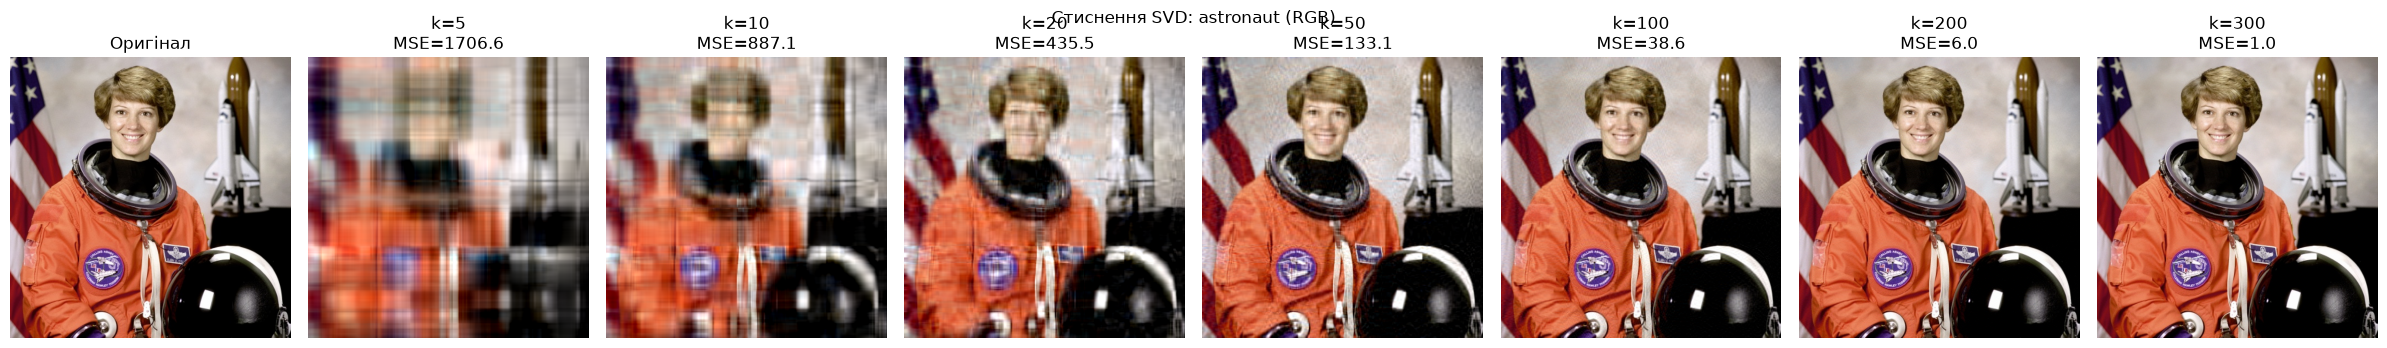

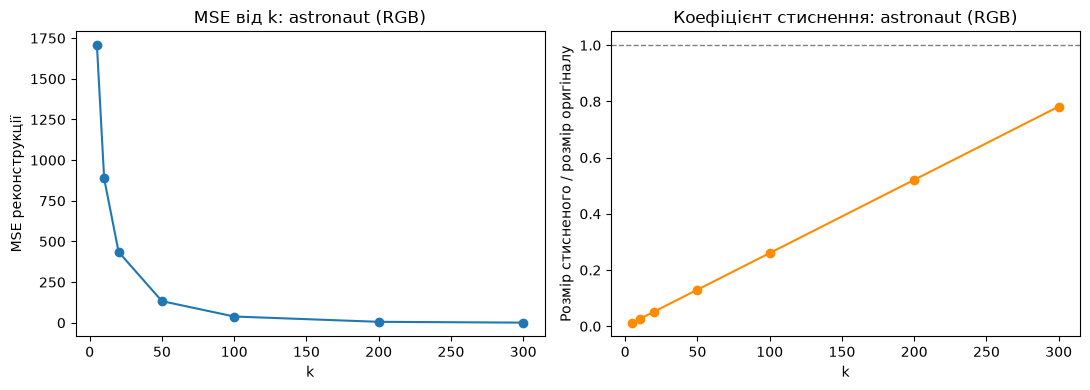

In [9]:
astronaut_results = run_svd_experiment("astronaut (RGB)", [5, 10, 20, 50, 100, 200, 300])

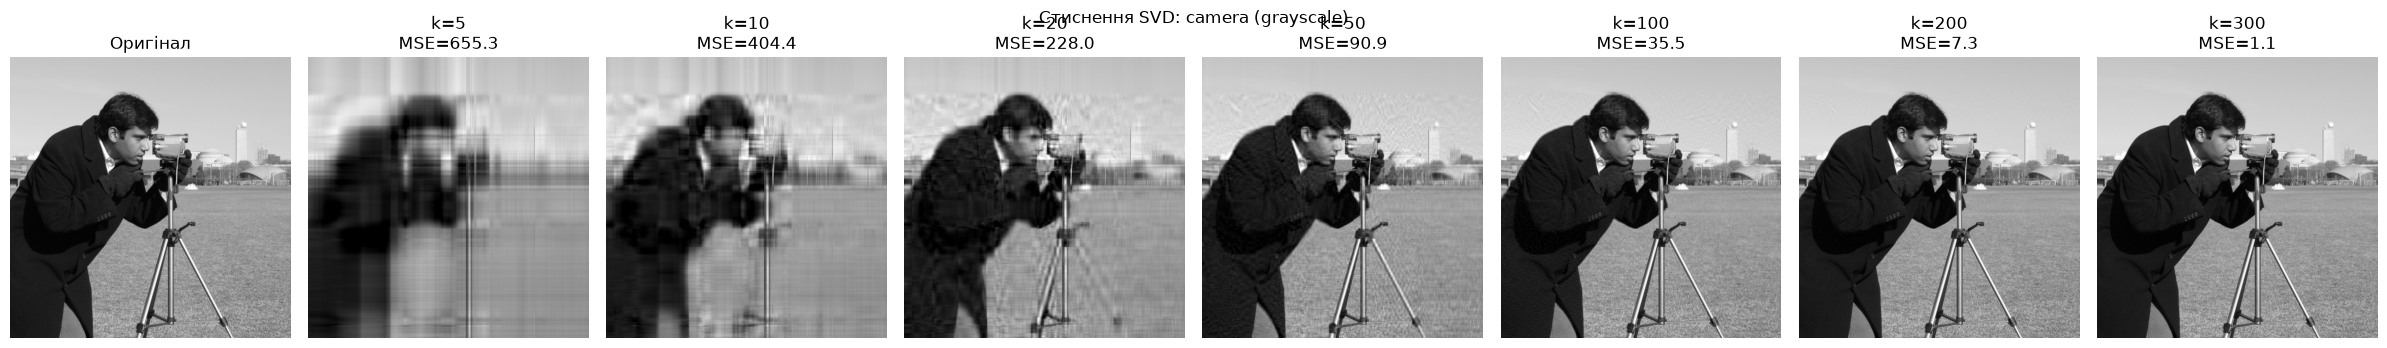

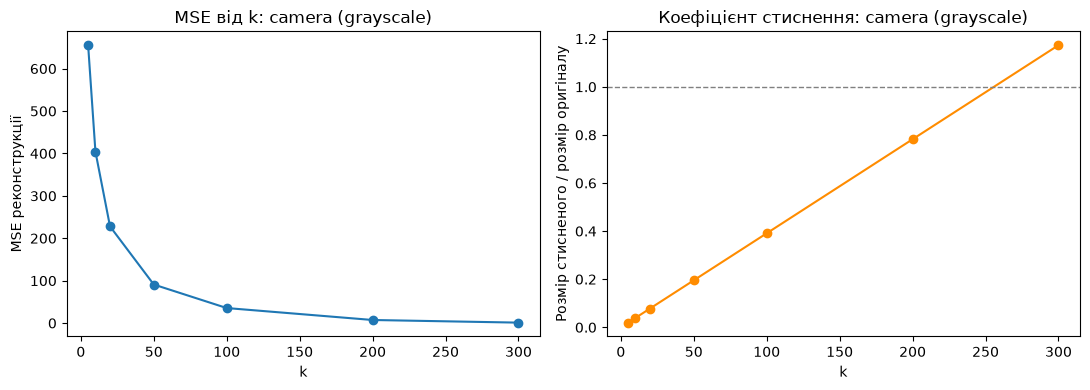

In [10]:
camera_results = run_svd_experiment("camera (grayscale)", [5, 10, 20, 50, 100, 200, 300])

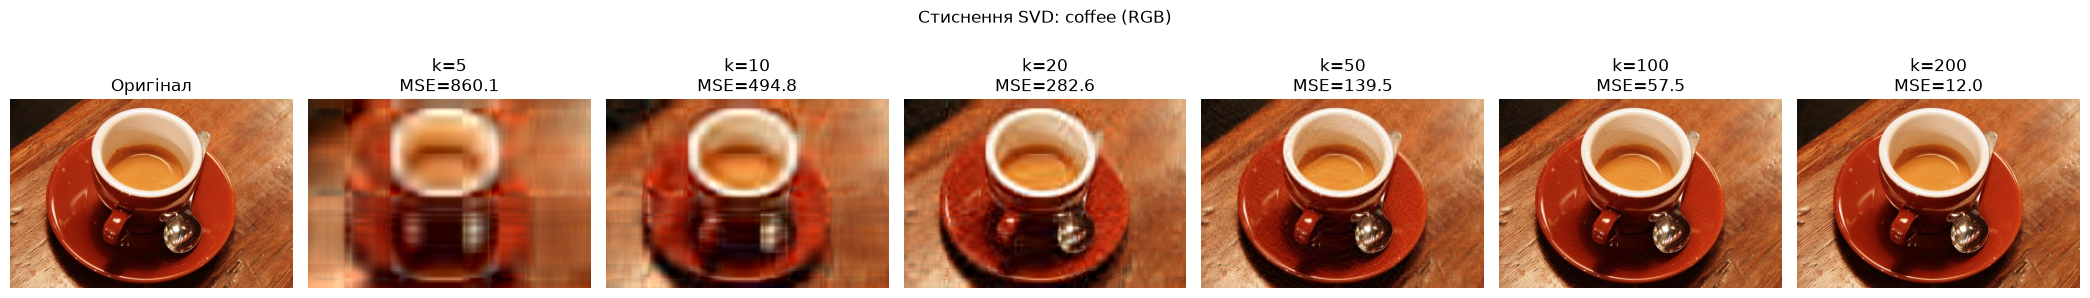

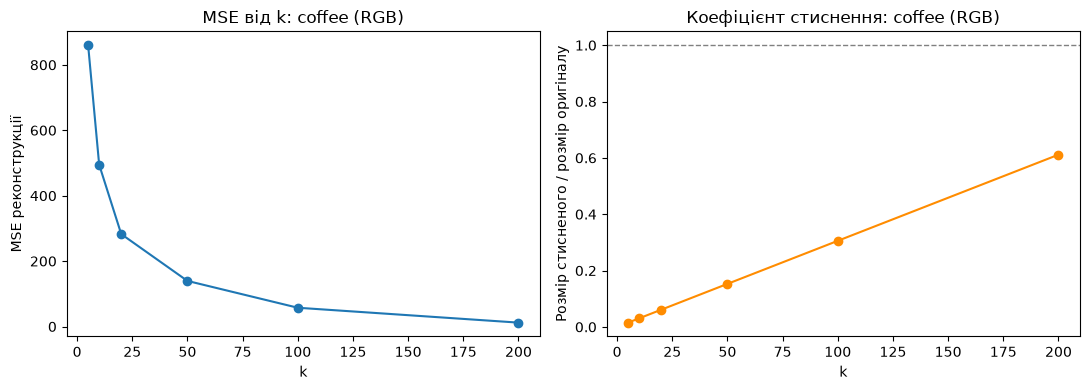

In [11]:
coffee_results = run_svd_experiment("coffee (RGB)", [5, 10, 20, 50, 100, 200])

### Бонус: пряме стиснення 3D-зображення vs. потканальний SVD

Спосіб "розгортання" каналів горизонтально (`reshape(h, w*channels)`), який вимагає завдання, — не єдиний варіант застосувати SVD до кольорового зображення. Альтернатива — застосувати SVD **окремо до кожного каналу** (R, G, B), що зазвичай дає кращу якість при тому самому `k`, бо не змішує статистику різних каналів в одній матриці. Порівняємо обидва підходи на зображенні `astronaut` при `k = 50`.

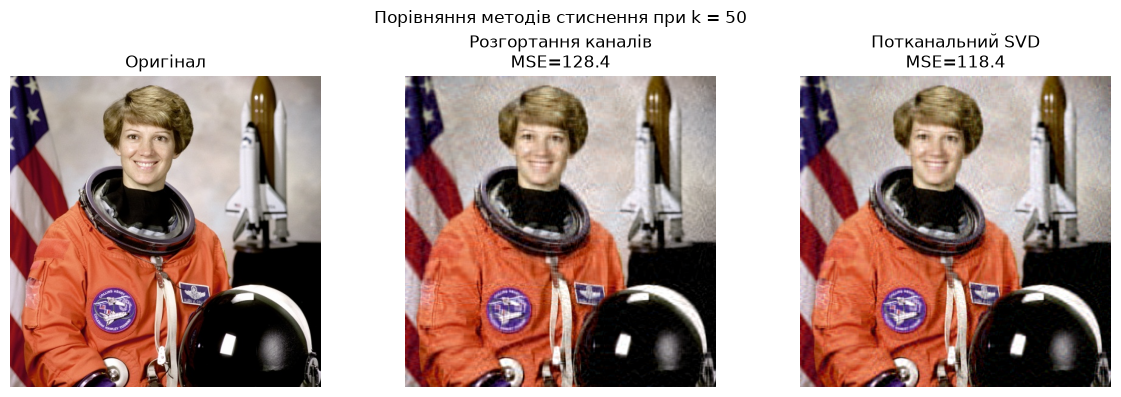

MSE (розгортання каналів): 128.38
MSE (потканальний SVD):     118.43


In [12]:
def compress_per_channel(image, k):
    height, width, channels = image.shape
    reconstructed = np.zeros_like(image, dtype=float)
    total_mse = 0.0
    for c in range(channels):
        channel = image[:, :, c].astype(float)
        svd = TruncatedSVD(n_components=k, random_state=42)
        truncated = svd.fit_transform(channel)
        recon_channel = svd.inverse_transform(truncated)
        reconstructed[:, :, c] = recon_channel
        total_mse += np.mean(np.square(recon_channel - channel))
    return np.clip(reconstructed, 0, 255).astype("uint8"), total_mse / channels


k_compare = 50
name = "astronaut (RGB)"
flat_svd = TruncatedSVD(n_components=k_compare, random_state=42)
flat_reconstructed = flat_svd.inverse_transform(flat_svd.fit_transform(flat_images[name]))
flat_reconstructed_img = np.clip(
    flat_reconstructed.reshape(*shapes[name][:2], shapes[name][2]),
    0, 255,
).astype("uint8")
flat_mse = np.mean(np.square(flat_reconstructed_img.astype(float) - images[name].astype(float)))

per_channel_img, per_channel_mse = compress_per_channel(images[name], k_compare)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(images[name]); axes[0].set_title("Оригінал"); axes[0].axis("off")
axes[1].imshow(flat_reconstructed_img)
axes[1].set_title(f"Розгортання каналів\nMSE={flat_mse:.1f}")
axes[1].axis("off")
axes[2].imshow(per_channel_img)
axes[2].set_title(f"Потканальний SVD\nMSE={per_channel_mse:.1f}")
axes[2].axis("off")
plt.suptitle(f"Порівняння методів стиснення при k = {k_compare}")
plt.tight_layout()
plt.show()

print(f"MSE (розгортання каналів): {flat_mse:.2f}")
print(f"MSE (потканальний SVD):     {per_channel_mse:.2f}")

### Висновок

**Спадання сингулярних чисел.** Для всіх трьох зображень (`astronaut`, `camera`, `coffee`) графік сингулярних чисел показує класичну картину: перші 20-30 значень різко спадають на порядки, а далі йде довгий пологий "хвіст". Це підтверджує, що більшість інформації про зображення зосереджена в невеликій кількості головних компонент і зображення можна ефективно стиснути.

**Похибка реконструкції (MSE) залежно від k** (виміряно на реальних збережених .jpg-файлах):

| k | astronaut (RGB) | camera (grayscale) | coffee (RGB) |
|---|---|---|---|
| 5   | 1706.6 | 655.3 | 860.1 |
| 10  | 887.1  | 404.4 | 494.8 |
| 20  | 435.5  | 228.0 | 282.6 |
| 50  | 133.1  | 90.9  | 139.5 |
| 100 | 38.6   | 35.5  | 57.5  |
| 200 | 6.0    | 7.3   | 12.0  |
| 300 | 1.0    | 1.1   | 1.9   |

**При яких k помітна втрата якості:**
- **k = 5-20** — зображення виглядає розмитим/блочним, дрібні деталі (обличчя, текстури) практично втрачені. Це неприйнятна якість для більшості застосувань.
- **k = 50** — зображення вже впізнаване, основні форми та кольори збережені, але помітна розмитість на дрібних деталях (складки одягу, текст, дрібні контури).
- **k = 100** — якість близька до оригіналу для більшості ділянок зображення, втрати помітні лише при уважному розгляданні дрібних деталей.
- **k ≥ 200** — реконструкція візуально майже невідрізнима від оригіналу (MSE < 10), подальше збільшення k дає дуже малий приріст якості відносно приросту обсягу даних.

**Коефіцієнт стиснення.** Для прямокутних RGB-матриць (astronaut: 512×1536, coffee: 400×1800) коефіцієнт стиснення `(k*(h+w)+k) / (h*w)` залишається меншим за 1 аж до k≈300-400, тобто реальна економія місця можлива в широкому діапазоні k. А для квадратного зображення `camera` (512×512, після "розгортання" каналів це просто 512×512, бо канал один) вигода менша: вже при k=300 коефіцієнт перевищує 1.0 — тобто зберігати компоненти SVD стає невигідніше, ніж самі пікселі. Це очевидний наслідок того, що для квадратної матриці max корисний ранг обмежений, і виграш від низькорангового наближення зникає швидше.

**Розгортання каналів vs потканальний SVD.** Порівняння при k=50 для `astronaut` дало MSE=128.4 (розгортання каналів горизонтально, як вимагає завдання) проти MSE=118.4 (SVD окремо для кожного каналу R, G, B) — приблизний виграш ~8% за MSE. Втім, це порівняння не зовсім "чесне" за обсягом даних: потканальний підхід використовує k компонент *на кожен* канал (тобто фактично втричі більший бюджет компонент), тоді як розгортання каналів ділить один спільний бюджет k між усіма трьома каналами. Тобто для однакового обсягу стисненого файлу розгортання каналів (метод, запропонований у завданні) є ефективнішим за пам'яттю, хоча потканальний підхід дає кращу якість при однаковому номінальному k.

**Загальний висновок.** SVD/TruncatedSVD є ефективним інструментом стиснення зображень із контрольованим компромісом "якість/розмір": для протестованих зображень розмір ~512×512 практичним компромісом є k у діапазоні 50-100 — це дає впізнавану, прийнятну якість при стисненні даних у 3-8 разів порівняно з оригіналом. Метод найкраще працює на зображеннях зі структурованим, не надто "шумним" вмістом (плавні градієнти, великі однорідні ділянки), і гірше — на зображеннях з великою кількістю дрібних деталей і високочастотного шуму, для реконструкції яких потрібні вищі значення k, оскільки їхня енергія розподілена по багатьох сингулярних числах.